<a href="https://colab.research.google.com/github/Tej-007-x/olora-split-cifar100-/blob/main/O_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# Cell 1: Install Dependencies
# O-LoRA for Continual Learning (Split-CIFAR100)
# ============================================================

In [1]:
!pip -q install torch torchvision torchaudio tqdm matplotlib numpy pandas scikit-learn

# ============================================================
# Cell 2: Import Libraries
# ============================================================


In [2]:
import os
import math
import random
import copy
import tarfile
import shutil
from dataclasses import dataclass
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset

from torchvision import transforms
from torchvision.datasets import CIFAR100
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("Libraries imported successfully.")

Libraries imported successfully.


# ============================================================
# Cell 3: Global Configuration
# ============================================================


In [3]:
@dataclass
class Config:
    # Dataset
    dataset_root: str = "/content/drive/MyDrive/Continual_Learning_Project/data"
    num_classes: int = 100
    num_tasks: int = 10
    classes_per_task: int = 10

    # Backbone
    pretrained: bool = True

    # O-LoRA
    rank: int = 16
    alpha: int = 8
    orth_lambda: float = 0.1

    # Training
    epochs: int = 1
    batch_size: int = 128
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    gradient_clip: float = 1.0

    # Optimizer / Scheduler
    optimizer: str = "AdamW"
    scheduler: str = "CosineAnnealingLR"

    # Misc
    seed: int = 42
    device: str = "cuda"
    num_workers: int = 0
    pin_memory: bool = True

    checkpoint_dir: str = "/content/drive/MyDrive/Continual_Learning_Project/checkpoints"
    results_dir: str = "/content/drive/MyDrive/Continual_Learning_Project/results"


CFG = Config()
os.makedirs(CFG.checkpoint_dir, exist_ok=True)
os.makedirs(CFG.results_dir, exist_ok=True)

print("=" * 70)
print("Configuration Loaded")
print("=" * 70)
for key, value in vars(CFG).items():
    print(f"{key:20s}: {value}")
print("=" * 70)


Configuration Loaded
dataset_root        : /content/drive/MyDrive/Continual_Learning_Project/data
num_classes         : 100
num_tasks           : 10
classes_per_task    : 10
pretrained          : True
rank                : 16
alpha               : 8
orth_lambda         : 0.1
epochs              : 1
batch_size          : 128
learning_rate       : 0.001
weight_decay        : 0.0001
gradient_clip       : 1.0
optimizer           : AdamW
scheduler           : CosineAnnealingLR
seed                : 42
device              : cuda
num_workers         : 0
pin_memory          : True
checkpoint_dir      : /content/drive/MyDrive/Continual_Learning_Project/checkpoints
results_dir         : /content/drive/MyDrive/Continual_Learning_Project/results


# ============================================================
# Cell 4: Seed & Device
# ============================================================


In [4]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CFG.device = str(device)
print(f"Device: {device}")

Device: cuda


# ============================================================
# Cell 5: Google Drive + Official CIFAR-100 Loading
# ============================================================

In [5]:
from google.colab import drive
import os
import shutil

mountpoint = "/content/drive"

# Check if the mountpoint exists and is not empty
if os.path.isdir(mountpoint) and len(os.listdir(mountpoint)) > 0:
    print(f"Mountpoint '{mountpoint}' exists and is not empty. Attempting to clean up...")
    try:
        # First, try to unmount if it's already mounted
        if os.path.ismount(mountpoint):
            drive.flush_and_unmount()
            print("Drive unmounted successfully.")
        # Then, remove the directory to ensure it's truly empty
        shutil.rmtree(mountpoint)
        print(f"Mountpoint '{mountpoint}' forcefully removed.")
        os.makedirs(mountpoint, exist_ok=True) # Recreate empty directory
    except Exception as e:
        print(f"Error during cleanup of mountpoint '{mountpoint}': {e}")
        print("Proceeding with mount attempt, but issues might persist.")

drive.mount(mountpoint, force_remount=True)

archive_path = None
print("Searching Google Drive for CIFAR-100...")
for root, _, files in os.walk("/content/drive/MyDrive"):
    for fname in files:
        if fname in ("cifar-100-python.tar.gz", "cifar-100-python_tar.gz"):
            archive_path = os.path.join(root, fname)
            break
    if archive_path:
        break

if archive_path is None:
    raise FileNotFoundError(
        "CIFAR-100 archive not found in Drive. Upload 'cifar-100-python.tar.gz' first."
    )
print(f"Archive found: {archive_path}")

DATA_ROOT = os.path.dirname(archive_path)
EXTRACT_FOLDER = os.path.join(DATA_ROOT, "cifar-100-python")
required_files = ["train", "test", "meta"]

dataset_ready = os.path.isdir(EXTRACT_FOLDER) and all(
    os.path.isfile(os.path.join(EXTRACT_FOLDER, f)) for f in required_files
)

if not dataset_ready:
    print("Extracting CIFAR-100...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(DATA_ROOT)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

for f in required_files:
    assert os.path.isfile(os.path.join(EXTRACT_FOLDER, f)), f"Missing {f}"

CFG.dataset_root = DATA_ROOT
print(f"Dataset root: {CFG.dataset_root}")

Mountpoint '/content/drive' exists and is not empty. Attempting to clean up...
Mountpoint '/content/drive' forcefully removed.
Mounted at /content/drive
Searching Google Drive for CIFAR-100...
Archive found: /content/drive/MyDrive/Colab Notebooks/O-LoRA/data/cifar-100-python.tar.gz
Dataset already extracted.
Dataset root: /content/drive/MyDrive/Colab Notebooks/O-LoRA/data


# ============================================================
# Cell 6: Data Transformations
# CNN Adaptation for Split-CIFAR100
# ============================================================

In [6]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

train_dataset = CIFAR100(root=CFG.dataset_root, train=True, download=False, transform=train_transform)
test_dataset = CIFAR100(root=CFG.dataset_root, train=False, download=False, transform=test_transform)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")


Train samples: 50000 | Test samples: 10000


# ============================================================
# Cell 7: Split-CIFAR100 Benchmark
# ============================================================


In [7]:
@dataclass
class TaskData:
    task_id: int
    classes: List[int]
    train_loader: DataLoader
    test_loader: DataLoader
    train_size: int
    test_size: int


class SplitCIFAR100Benchmark:
    def __init__(self, train_dataset, test_dataset, cfg):
        self.cfg = cfg
        self.tasks: List[TaskData] = []
        self.seen_tasks: List[int] = []
        self._build(train_dataset, test_dataset)

    def _build(self, train_dataset, test_dataset):
        train_targets = np.array(train_dataset.targets)
        test_targets = np.array(test_dataset.targets)

        for task_id in range(self.cfg.num_tasks):
            start = task_id * self.cfg.classes_per_task
            end = start + self.cfg.classes_per_task
            classes = list(range(start, end))

            train_idx = np.where(np.isin(train_targets, classes))[0]
            test_idx = np.where(np.isin(test_targets, classes))[0]

            train_subset = Subset(train_dataset, train_idx.tolist())
            test_subset = Subset(test_dataset, test_idx.tolist())

            train_loader = DataLoader(
                train_subset, batch_size=self.cfg.batch_size, shuffle=True,
                num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
            )
            test_loader = DataLoader(
                test_subset, batch_size=self.cfg.batch_size, shuffle=False,
                num_workers=self.cfg.num_workers, pin_memory=self.cfg.pin_memory
            )

            self.tasks.append(TaskData(
                task_id=task_id, classes=classes,
                train_loader=train_loader, test_loader=test_loader,
                train_size=len(train_subset), test_size=len(test_subset)
            ))

    def get_dataloaders(self, task_id):
        t = self.tasks[task_id]
        return t.train_loader, t.test_loader

    def mark_task_completed(self, task_id):
        if task_id not in self.seen_tasks:
            self.seen_tasks.append(task_id)

    def get_seen_tasks(self):
        return self.seen_tasks

    def summary(self):
        print("=" * 70)
        print("Split-CIFAR100 Benchmark")
        print("=" * 70)
        for t in self.tasks:
            print(f"Task {t.task_id:2d} | Classes {t.classes[0]:2d}-{t.classes[-1]:2d} "
                  f"| Train {t.train_size:5d} | Test {t.test_size:5d}")
        print("=" * 70)


benchmark = SplitCIFAR100Benchmark(train_dataset, test_dataset, CFG)
benchmark.summary()


Split-CIFAR100 Benchmark
Task  0 | Classes  0- 9 | Train  5000 | Test  1000
Task  1 | Classes 10-19 | Train  5000 | Test  1000
Task  2 | Classes 20-29 | Train  5000 | Test  1000
Task  3 | Classes 30-39 | Train  5000 | Test  1000
Task  4 | Classes 40-49 | Train  5000 | Test  1000
Task  5 | Classes 50-59 | Train  5000 | Test  1000
Task  6 | Classes 60-69 | Train  5000 | Test  1000
Task  7 | Classes 70-79 | Train  5000 | Test  1000
Task  8 | Classes 80-89 | Train  5000 | Test  1000
Task  9 | Classes 90-99 | Train  5000 | Test  1000


# ============================================================
# Cell 8: O-LoRA Conv2D Layer
# ============================================================


In [9]:
class OLoRASubspace(nn.Module):
    def __init__(self, out_features: int, in_features: int, rank: int, alpha: float):
        super().__init__()
        self.rank = rank
        self.scaling = alpha / rank
        self.A = nn.Parameter(torch.empty(out_features, rank))   # matches paper's A in R^(d x r)
        self.B = nn.Parameter(torch.empty(rank, in_features))    # matches paper's B in R^(r x k)
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.zeros_(self.B)   # B=0 at init -> adapter starts as a no-op

    def delta(self) -> torch.Tensor:
        return (self.A @ self.B) * self.scaling

    def freeze(self):
        self.A.requires_grad = False
        self.B.requires_grad = False


class OLoRAConv2d(nn.Module):
    """Frozen base conv + task adapters. Finished tasks get merged into conv.weight permanently."""

    def __init__(self, conv_layer: nn.Conv2d, rank: int, alpha: float):
        super().__init__()
        self.conv = conv_layer
        for p in self.conv.parameters():
            p.requires_grad = False

        self.out_channels = conv_layer.out_channels
        self.in_channels = conv_layer.in_channels
        self.kernel_size = conv_layer.kernel_size
        self.stride = conv_layer.stride
        self.padding = conv_layer.padding
        self.dilation = conv_layer.dilation
        self.groups = conv_layer.groups
        self.in_features = self.in_channels * self.kernel_size[0] * self.kernel_size[1]

        self.rank = rank
        self.alpha = alpha

        self.adapters = nn.ModuleDict()   # kept forever (frozen after merge) - needed for orthogonality
        self.active_task = None            # task currently being trained (unmerged)

    def add_task(self, task_id: int):
        task_name = str(task_id)
        adapter = OLoRASubspace(self.out_channels, self.in_features, self.rank, self.alpha)
        self.adapters[task_name] = adapter.to(self.conv.weight.device)
        self.active_task = task_name

    def merge_active_task(self):
        if self.active_task is None:
            return
        name = self.active_task
        with torch.no_grad():
            delta = self.adapters[name].delta().view_as(self.conv.weight)
            self.conv.weight.data += delta
        self.adapters[name].freeze()
        self.active_task = None

    def get_A_matrix(self, task_id: int) -> torch.Tensor:
        return self.adapters[str(task_id)].A   # (out_channels, rank)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        weight = self.conv.weight
        if self.active_task is not None:
            delta = self.adapters[self.active_task].delta().view_as(weight)
            weight = weight + delta
        return F.conv2d(
            x, weight, bias=self.conv.bias,
            stride=self.stride, padding=self.padding,
            dilation=self.dilation, groups=self.groups
        )


# ============================================================
# Cell 9: O-LoRA ResNet18
# ============================================================


In [10]:
class OLoRAResNet18(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT if cfg.pretrained else None)

        # CIFAR-sized input adaptation (32x32 images, not ImageNet's 224x224)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()

        for param in self.backbone.parameters():
            param.requires_grad = False

        self._inject_olora()

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, cfg.num_classes)   # single shared classifier
        for p in self.backbone.fc.parameters():
            p.requires_grad = True

    def _inject_olora(self):
        for stage_name in ["layer1", "layer2", "layer3", "layer4"]:
            stage = getattr(self.backbone, stage_name)
            for block in stage:
                if isinstance(block.conv1, nn.Conv2d) and block.conv1.kernel_size == (3, 3):
                    block.conv1 = OLoRAConv2d(block.conv1, rank=self.cfg.rank, alpha=self.cfg.alpha)
                if isinstance(block.conv2, nn.Conv2d) and block.conv2.kernel_size == (3, 3):
                    block.conv2 = OLoRAConv2d(block.conv2, rank=self.cfg.rank, alpha=self.cfg.alpha)

    def add_task(self, task_id):
        for module in self.modules():
            if isinstance(module, OLoRAConv2d):
                module.add_task(task_id)
        self.backbone.fc.weight.requires_grad = True
        self.backbone.fc.bias.requires_grad = True

    def merge_active_task(self):
        for module in self.modules():
            if isinstance(module, OLoRAConv2d):
                module.merge_active_task()

    def get_olora_layers(self):
        return [m for m in self.modules() if isinstance(m, OLoRAConv2d)]

    def trainable_parameters(self):
        return [p for p in self.parameters() if p.requires_grad]

    def forward(self, x):
        return self.backbone(x)


# Sanity check
_sanity_model = OLoRAResNet18(CFG)
_sanity_model.add_task(0)
_trainable = sum(p.numel() for p in _sanity_model.parameters() if p.requires_grad)
_total = sum(p.numel() for p in _sanity_model.parameters())
_x = torch.randn(2, 3, 32, 32)
_y = _sanity_model(_x)
print(f"Sanity check -> Trainable: {_trainable:,} | Total: {_total:,} | Output shape: {_y.shape}")
del _sanity_model


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


Sanity check -> Trainable: 601,188 | Total: 11,770,020 | Output shape: torch.Size([2, 100])


# ============================================================
# Cell 10: Orthogonality Loss
# ============================================================


In [11]:
"""
Purpose
-------
Implements the orthogonality regularization proposed
in the O-LoRA paper.

Relation to Paper
-----------------
Paper Eq.(6):
    O_{i,t} = A_i^T A_t

Paper Eq.(7)-(8):
    L_total = L_ce + λ1 * L_orth

CNN Adaptation
--------------
The convolution kernel is flattened into a matrix.

Only matrix A participates in the orthogonality loss.

To make the regularization independent of the number
of adapted convolution layers, we normalize the
accumulated loss by the total number of overlap
elements. This normalization is a CNN adaptation
and is not explicitly described in the paper.
"""

import torch
import torch.nn as nn


class OrthogonalityLoss(nn.Module):
    def forward(self, model: OLoRAResNet18, current_task: int) -> torch.Tensor:
        device = next(model.parameters()).device
        if current_task == 0:
            return torch.tensor(0.0, device=device)

        loss = torch.tensor(0.0, device=device)
        num_constraints = 0
        current_name = str(current_task)

        for layer in model.get_olora_layers():
            if current_name not in layer.adapters:
                continue
            A_t = layer.get_A_matrix(current_task)   # (out_channels, rank)

            for past_task in range(current_task):
                A_i = layer.get_A_matrix(past_task)   # (out_channels, rank)
                O_it = A_i.t() @ A_t                  # (rank, rank) - correct, small
                loss = loss + torch.sum(O_it ** 2)
                num_constraints += 1

        if num_constraints > 0:
            loss = loss / num_constraints
        return loss


# ============================================================
# Cell 11: Optimizer & Scheduler Setup
# ============================================================


In [12]:
"""
Purpose
-------
Configure the optimizer for Continual Learning.

Relation to Paper
-----------------
Since previous tasks' O-LoRA adapters are completely frozen,
the optimizer MUST ONLY update:
  1. The active task's O-LoRA adapter (Matrix A and B)
  2. The classification head

This ensures zero interference with previously learned weights
at the gradient update level, maintaining the strict
orthogonality constraints.
"""

import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

def build_optimizer(model, cfg):
    trainable_params = model.trainable_parameters()
    if cfg.optimizer == "AdamW":
        return optim.AdamW(trainable_params, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    elif cfg.optimizer == "Adam":
        return optim.Adam(trainable_params, lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    elif cfg.optimizer == "SGD":
        return optim.SGD(trainable_params, lr=cfg.learning_rate, momentum=0.9, weight_decay=cfg.weight_decay)
    raise ValueError(f"Unsupported optimizer: {cfg.optimizer}")


def build_scheduler(optimizer, cfg, dataloader_length):
    if cfg.scheduler == "CosineAnnealingLR":
        total_steps = cfg.epochs * dataloader_length
        return CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)
    return None

# ============================================================
# Cell 12: Training & Evaluation Engines
# ============================================================



In [13]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Training Engine
# ------------------------------------------------------------

def train_one_task(model, train_loader, optimizer, scheduler, criterion_ce, criterion_orth, task_id, cfg):
    model.train()
    class_start = task_id * cfg.classes_per_task
    class_end = class_start + cfg.classes_per_task

    for epoch in range(cfg.epochs):
        running_loss, correct, total = 0.0, 0, 0
        progress = tqdm(train_loader, desc=f"Task {task_id} | Epoch {epoch+1}/{cfg.epochs}", leave=False)

        for images, labels in progress:
            images, labels = images.to(cfg.device), labels.to(cfg.device)
            relative_labels = labels - class_start

            optimizer.zero_grad()
            full_logits = model(images)
            task_logits = full_logits[:, class_start:class_end]
            loss_ce = criterion_ce(task_logits, relative_labels)

            if task_id > 0:
                loss_orth = criterion_orth(model, current_task=task_id)
                loss_total = loss_ce + (cfg.orth_lambda * loss_orth)
            else:
                loss_orth = torch.tensor(0.0)
                loss_total = loss_ce

            loss_total.backward()
            torch.nn.utils.clip_grad_norm_(model.trainable_parameters(), cfg.gradient_clip)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            running_loss += loss_total.item()
            predictions = task_logits.argmax(dim=1)
            correct += (predictions == relative_labels).sum().item()
            total += relative_labels.size(0)
            progress.set_postfix({"Loss": f"{loss_total.item():.3f}"})

        epoch_acc = 100.0 * correct / total
        print(f"  -> Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Acc: {epoch_acc:.2f}%")


@torch.no_grad()
def evaluate_task(model, test_loader, task_id, cfg):
    model.eval()
    class_start = task_id * cfg.classes_per_task
    class_end = class_start + cfg.classes_per_task

    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(cfg.device), labels.to(cfg.device)
        relative_labels = labels - class_start
        full_logits = model(images)
        task_logits = full_logits[:, class_start:class_end]
        predictions = task_logits.argmax(dim=1)
        correct += (predictions == relative_labels).sum().item()
        total += labels.size(0)

    return 100.0 * correct / total

# ============================================================
# Cell 13: Reusable pipeline runner
# ============================================================


In [14]:
def run_olora_pipeline(cfg, run_name: str = "run"):
    print("=" * 80)
    print(f"STARTING RUN: {run_name}  (orth_lambda = {cfg.orth_lambda})")
    print("=" * 80)

    local_benchmark = SplitCIFAR100Benchmark(train_dataset, test_dataset, cfg)
    model = OLoRAResNet18(cfg)
    model.to(cfg.device)

    accuracy_matrix = np.zeros((cfg.num_tasks, cfg.num_tasks))
    criterion_ce = nn.CrossEntropyLoss()
    criterion_orth = OrthogonalityLoss()

    for task_id in range(cfg.num_tasks):
        print(f"\n{'*'*50}\n[{run_name}] Task {task_id} / {cfg.num_tasks - 1}\n{'*'*50}")

        train_loader, _ = local_benchmark.get_dataloaders(task_id)
        model.add_task(task_id)
        optimizer = build_optimizer(model, cfg)
        scheduler = build_scheduler(optimizer, cfg, len(train_loader))

        train_one_task(model, train_loader, optimizer, scheduler, criterion_ce, criterion_orth, task_id, cfg)

        model.merge_active_task()
        local_benchmark.mark_task_completed(task_id)

        for seen_task in local_benchmark.get_seen_tasks():
            _, eval_loader = local_benchmark.get_dataloaders(seen_task)
            acc = evaluate_task(model, eval_loader, seen_task, cfg)
            accuracy_matrix[task_id, seen_task] = acc
            print(f"  -> Task {seen_task} Accuracy: {acc:.2f}%")

    final_accuracies = accuracy_matrix[-1, :]
    avg_accuracy = np.mean(final_accuracies)

    forgetting_scores = []
    for t in range(cfg.num_tasks - 1):
        best_acc = np.max(accuracy_matrix[:, t])
        final_acc = accuracy_matrix[-1, t]
        forgetting_scores.append(best_acc - final_acc)
    avg_forgetting = np.mean(forgetting_scores)

    print(f"\n[{run_name}] Final Average Accuracy (AA)   : {avg_accuracy:.2f}%")
    print(f"[{run_name}] Final Average Forgetting (AF) : {avg_forgetting:.2f}%")

    return accuracy_matrix, avg_accuracy, avg_forgetting


# ============================================================
# Cell 14: Run the comparison experiment (core result for the report)
# ============================================================


In [15]:
cfg_no_orth = copy.deepcopy(CFG)
cfg_no_orth.orth_lambda = 0.0

cfg_with_orth = copy.deepcopy(CFG)
cfg_with_orth.orth_lambda = 0.1

acc_matrix_no_orth, aa_no_orth, af_no_orth = run_olora_pipeline(cfg_no_orth, run_name="No-Orthogonality (lambda=0)")
acc_matrix_with_orth, aa_with_orth, af_with_orth = run_olora_pipeline(cfg_with_orth, run_name="O-LoRA (lambda=0.1)")

print("\n" + "=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Method':<30} {'Avg Accuracy':>15} {'Avg Forgetting':>18}")
print("-" * 70)
print(f"{'No Orthogonality (λ=0)':<30} {aa_no_orth:>14.2f}% {af_no_orth:>17.2f}%")
print(f"{'O-LoRA (λ=0.1)':<30} {aa_with_orth:>14.2f}% {af_with_orth:>17.2f}%")
print("=" * 70)
print(f"Forgetting reduced by: {af_no_orth - af_with_orth:+.2f} percentage points")
print(f"Accuracy improved by : {aa_with_orth - aa_no_orth:+.2f} percentage points")
print("=" * 70)


STARTING RUN: No-Orthogonality (lambda=0)  (orth_lambda = 0.0)

**************************************************
[No-Orthogonality (lambda=0)] Task 0 / 9
**************************************************


Task 0 | Epoch 1/1:   0%|          | 0/40 [00:00<?, ?it/s]

  -> Epoch 1 | Loss: 1.6812 | Acc: 42.64%
  -> Task 0 Accuracy: 55.40%

**************************************************
[No-Orthogonality (lambda=0)] Task 1 / 9
**************************************************


Task 1 | Epoch 1/1:   0%|          | 0/40 [00:00<?, ?it/s]

  -> Epoch 1 | Loss: 1.6853 | Acc: 40.92%
  -> Task 0 Accuracy: 47.00%
  -> Task 1 Accuracy: 56.40%

**************************************************
[No-Orthogonality (lambda=0)] Task 2 / 9
**************************************************


...

  -> Epoch 1 | Loss: 3.1959 | Acc: 55.68%
  -> Task 0 Accuracy: 29.20%
  -> Task 1 Accuracy: 27.90%
  -> Task 2 Accuracy: 37.50%
  -> Task 3 Accuracy: 40.10%
  -> Task 4 Accuracy: 41.10%
  -> Task 5 Accuracy: 50.30%
  -> Task 6 Accuracy: 60.80%
  -> Task 7 Accuracy: 66.00%

**************************************************
[O-LoRA (lambda=0.1)] Task 8 / 9
**************************************************


Task 8 | Epoch 1/1:   0%|          | 0/40 [00:00<?, ?it/s]

  -> Epoch 1 | Loss: 3.2905 | Acc: 52.20%
  -> Task 0 Accuracy: 22.30%
  -> Task 1 Accuracy: 29.90%
  -> Task 2 Accuracy: 39.90%
  -> Task 3 Accuracy: 37.10%
  -> Task 4 Accuracy: 38.80%
  -> Task 5 Accuracy: 46.10%
  -> Task 6 Accuracy: 53.10%
  -> Task 7 Accuracy: 58.30%
  -> Task 8 Accuracy: 64.30%

**************************************************
[O-LoRA (lambda=0.1)] Task 9 / 9
**************************************************


Task 9 | Epoch 1/1:   0%|          | 0/40 [00:00<?, ?it/s]

  -> Epoch 1 | Loss: 3.1212 | Acc: 62.64%
  -> Task 0 Accuracy: 19.00%
  -> Task 1 Accuracy: 29.40%
  -> Task 2 Accuracy: 36.80%
  -> Task 3 Accuracy: 36.00%
  -> Task 4 Accuracy: 37.10%
  -> Task 5 Accuracy: 44.00%
  -> Task 6 Accuracy: 55.20%
  -> Task 7 Accuracy: 57.30%
  -> Task 8 Accuracy: 53.50%
  -> Task 9 Accuracy: 72.50%

[O-LoRA (lambda=0.1)] Final Average Accuracy (AA)   : 44.08%
[O-LoRA (lambda=0.1)] Final Average Forgetting (AF) : 22.27%

COMPARISON SUMMARY
Method                            Avg Accuracy     Avg Forgetting
----------------------------------------------------------------------
No Orthogonality (λ=0)                  40.72%             26.51%
O-LoRA (λ=0.1)                          44.08%             22.27%
Forgetting reduced by: +4.24 percentage points
Accuracy improved by : +3.36 percentage points


# ============================================================
# Cell 15: Save results
# ============================================================



In [17]:
import os

os.makedirs(CFG.results_dir, exist_ok=True)
np.save(os.path.join(CFG.results_dir, "acc_matrix_no_orth.npy"), acc_matrix_no_orth)
np.save(os.path.join(CFG.results_dir, "acc_matrix_with_orth.npy"), acc_matrix_with_orth)
print(f"Results saved to {CFG.results_dir}")

Results saved to /content/drive/MyDrive/Continual_Learning_Project/results


# ============================================================
# Cell 16: Plots (heatmaps + forgetting curve comparison)
# ============================================================


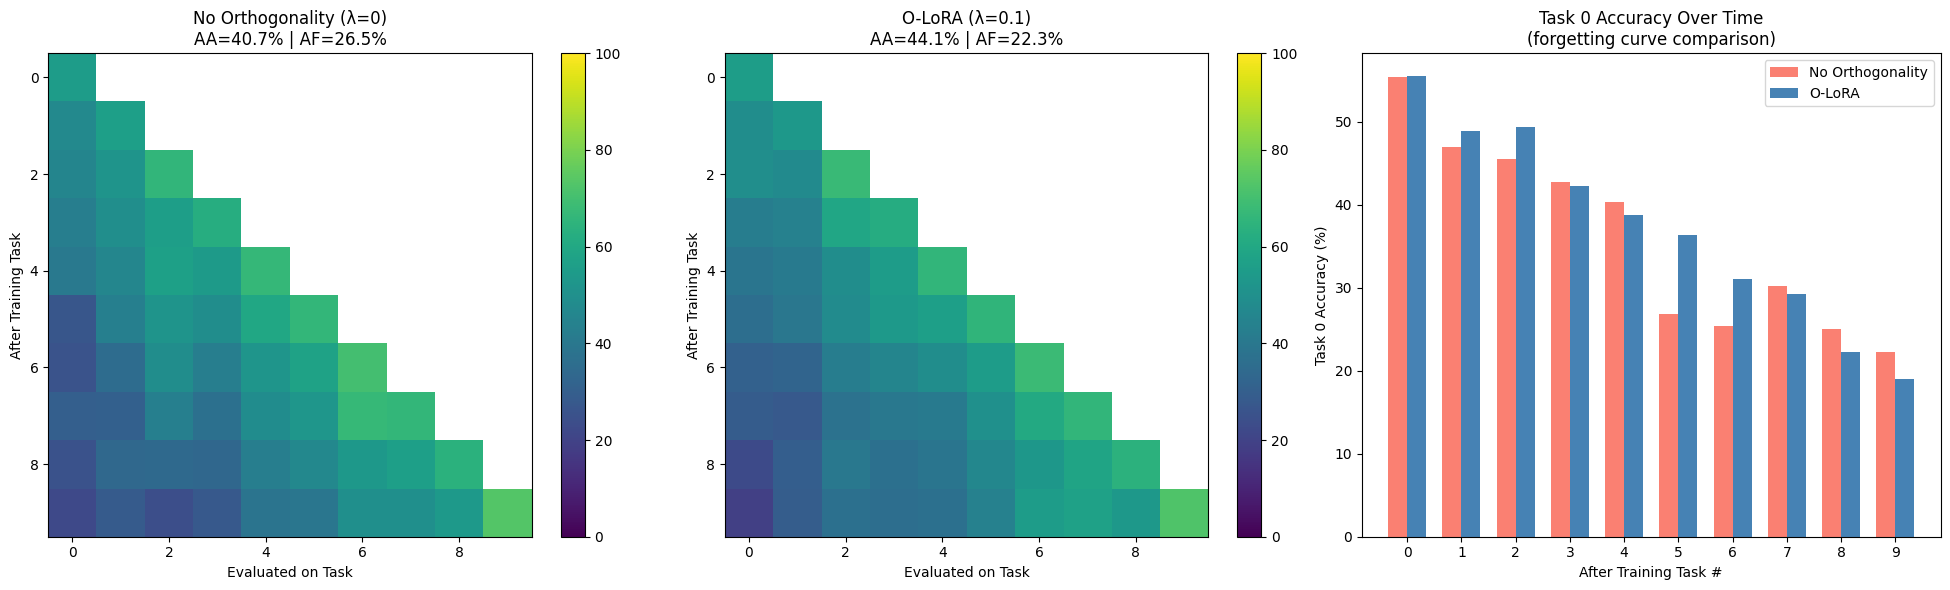

Comparison plot saved.


In [18]:
def plot_comparison(acc_no_orth, acc_with_orth, aa_no_orth, af_no_orth, aa_with_orth, af_with_orth, cfg):
    num_tasks = cfg.num_tasks
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    mask = np.triu(np.ones_like(acc_no_orth, dtype=bool), k=1)

    display1 = np.where(mask, np.nan, acc_no_orth)
    im1 = axes[0].imshow(display1, cmap="viridis", vmin=0, vmax=100)
    axes[0].set_title(f"No Orthogonality (λ=0)\nAA={aa_no_orth:.1f}% | AF={af_no_orth:.1f}%")
    axes[0].set_xlabel("Evaluated on Task")
    axes[0].set_ylabel("After Training Task")
    fig.colorbar(im1, ax=axes[0], fraction=0.046)

    display2 = np.where(mask, np.nan, acc_with_orth)
    im2 = axes[1].imshow(display2, cmap="viridis", vmin=0, vmax=100)
    axes[1].set_title(f"O-LoRA (λ=0.1)\nAA={aa_with_orth:.1f}% | AF={af_with_orth:.1f}%")
    axes[1].set_xlabel("Evaluated on Task")
    axes[1].set_ylabel("After Training Task")
    fig.colorbar(im2, ax=axes[1], fraction=0.046)

    x = np.arange(num_tasks)
    width = 0.35
    axes[2].bar(x - width/2, acc_no_orth[:, 0], width, label="No Orthogonality", color="salmon")
    axes[2].bar(x + width/2, acc_with_orth[:, 0], width, label="O-LoRA", color="steelblue")
    axes[2].set_title("Task 0 Accuracy Over Time\n(forgetting curve comparison)")
    axes[2].set_xlabel("After Training Task #")
    axes[2].set_ylabel("Task 0 Accuracy (%)")
    axes[2].legend()
    axes[2].set_xticks(x)

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.results_dir, "olora_comparison.png"), dpi=150)
    plt.show()


plot_comparison(acc_matrix_no_orth, acc_matrix_with_orth, aa_no_orth, af_no_orth, aa_with_orth, af_with_orth, CFG)
print("Comparison plot saved.")

